# Classification: Exercise

This exercise covers binary classification on the **Breast Cancer Wisconsin Dataset** (`datasets/breast_cancer.csv`).

Each sample represents a digitized biopsy image with 30 numeric features computed from cell nuclei measurements. The target is the **diagnosis** label: **Malignant (M)** or **Benignant (B)**.

| Column | Description |
|--------|-------------|
| `ID number` | Patient identifier (not used for modelling) |
| `diagnosis` | Target - **M** (Malignant) or **B** (Benignant) |
| `radius mean` | Mean of distances from centre to perimeter |
| `texture mean` | Standard deviation of grey-scale values |
| `perimeter mean` | Mean nucleus perimeter |
| `area mean` | Mean nucleus area |
| `smoothness mean` | Mean local variation in radius lengths |
| `compactness mean` | Mean of perimeter² / area − 1.0 |
| `concavity mean` | Mean severity of concave portions of contour |
| `concave points mean` | Mean number of concave portions of contour |
| `symmetry mean` | Mean nucleus symmetry |
| `fractal dimension mean` | Mean coastline approximation − 1 |
| *(+ 20 more: SE and worst values for each of the 10 measurements above)* | |

**The final model must satisfy all three criteria:**

- Accuracy on the test set ≥ 0.98
- AUC on the test set ≥ 0.98
- Recall = 1 for the malignant class (zero false negatives - no malignant tumour is missed)

---

**Methodology:**

1. The target column is encoded as a binary integer: Malignant = 1 (positive class), Benignant = 0 (negative class).
2. Features are standardised (zero mean, unit variance) so the SVM kernel operates on comparable scales.
3. An **SVM with RBF kernel** is trained as the primary classifier.
4. The decision threshold is tuned to guarantee **Recall = 1**: in medical diagnostics, a false negative (malignant tumour classified as benignant) is far more dangerous than a false positive.
5. The model is evaluated with a **confusion matrix** and a **ROC curve**.
6. Final predictions are produced for new patients in `breast_cancer_pred.csv` and saved to an Excel file.

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, recall_score, accuracy_score
)

RANDOM_SEED = 42  # fixed seed for reproducibility

## Step 1 - Data Loading

The dataset is loaded from a CSV file. It contains 563 samples and 32 columns (patient ID, diagnosis target, and 30 numeric features). A preview of the first rows is shown to verify the structure.

In [101]:
df = pd.read_csv('datasets/breast_cancer.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (563, 32)


,ID number,diagnosis,radius mean,texture mean,perimeter mean,area mean,smoothness mean,compactness mean,concavity mean,concave points mean,...,radius worst,texture worst,perimeter worst,area worst,smoothness worstse,compactness worst,concavity worst,concave points worst,symmetry worst,fractal dimension worst
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


## Step 2 - Exploratory Data Analysis

The class distribution is inspected to determine whether the dataset is **balanced** or **imbalanced**. A significant imbalance between benignant and malignant samples can bias a classifier toward the majority class, producing high accuracy but poor recall on the minority (and clinically critical) class.

Missing values are also verified: since this is a curated dataset, no imputation is expected to be necessary.

Class distribution:
diagnosis
B    353
M    210
Name: count, dtype: int64

Benignant : 353 (62.7%)
Malignant : 210 (37.3%)

Missing values: 0


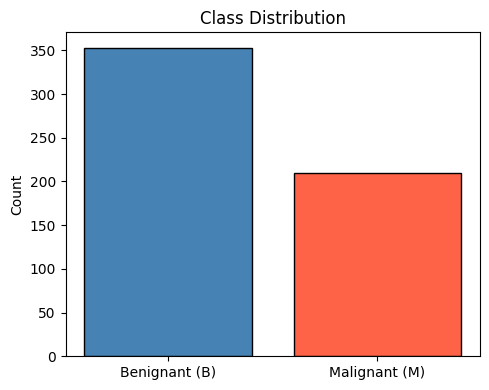

In [102]:
print('Class distribution:')
print(df['diagnosis'].value_counts())
print()
print(f"Benignant : {(df['diagnosis']=='B').sum()} ({(df['diagnosis']=='B').mean()*100:.1f}%)")
print(f"Malignant : {(df['diagnosis']=='M').sum()} ({(df['diagnosis']=='M').mean()*100:.1f}%)")
print()
print(f'Missing values: {df.isnull().sum().sum()}')

fig, ax = plt.subplots(figsize=(5, 4))
counts = df['diagnosis'].value_counts()
ax.bar(['Benignant (B)', 'Malignant (M)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

## Step 3 - Preprocessing

Two preprocessing operations are applied before modelling:

1. **Target encoding:** the `diagnosis` column is mapped to a binary integer - Malignant = 1 (positive class), Benignant = 0 (negative class). Designating malignant as the positive class ensures that standard metrics such as precision, recall, and AUC are computed with respect to the class of primary clinical interest.
2. **ID removal:** the `ID number` column is a patient identifier with no predictive relationship to the diagnosis; it is dropped before constructing the feature matrix.

In [103]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})  # Malignant=1 (positive), Benignant=0

X = df.drop(columns=['ID number', 'diagnosis']).values   # feature matrix: 563 x 30
y = df['diagnosis'].values                                # target vector: 563 labels

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Class balance - Benignant: {(y==0).sum()}, Malignant: {(y==1).sum()}')

Feature matrix shape : (563, 30)
Target vector shape  : (563,)
Class balance - Benignant: 353, Malignant: 210


## Step 4 - Train/Test Split & Standardisation

The data is split into a **training set** (70%) and a **test set** (30%). A 70/30 split provides a sufficiently large test set for reliable estimation of rare-event metrics such as recall and AUC.

**Standardisation** (`StandardScaler`) rescales every feature to mean = 0 and standard deviation = 1. This step is essential for SVM: the RBF kernel computes Euclidean distances between data points in feature space, so features on larger scales would dominate the distance metric without normalisation.

> The scaler is fitted on the training set only and then applied to the test set to prevent data leakage.

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # compute mean/std from train, then scale
X_test  = scaler.transform(X_test)       # apply the same scaling to test

print(f'Train: {X_train.shape[0]} samples')
print(f'Test: {X_test.shape[0]} samples')

Train: 394 samples
Test: 169 samples


## Step 5 - Model Training

A **Support Vector Machine with RBF kernel** (`SVC`) is used as the primary classifier. SVM finds the maximum-margin hyperplane separating the two classes in a high-dimensional feature space. The RBF kernel implicitly maps the 30 standardised features into an infinite-dimensional space, enabling non-linear decision boundaries.

Key hyperparameters:
- **`C = 10`** - regularisation parameter; a higher value penalises misclassifications more and fits the training data more closely.
- **`gamma = 'scale'`** - kernel coefficient set automatically to `1 / (n_features × Var(X))`, adapting to the feature variance.
- **`probability = True`** - enables `predict_proba`, required for threshold tuning and AUC computation (internally uses Platt scaling).

In [105]:
model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_SEED)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


## Step 6 - Baseline Evaluation

The model is first evaluated at the **default decision threshold of 0.5**: a sample is predicted as malignant when the estimated probability of the malignant class exceeds 50%.

The classification report shows precision, recall, and F1-score for both classes, providing a complete picture of performance before any threshold adjustment.

In [106]:
y_pred_default = model.predict(X_test)

print('Baseline evaluation (threshold = 0.5):')
print(classification_report(y_test, y_pred_default, target_names=['Benignant', 'Malignant']))

Baseline evaluation (threshold = 0.5):
              precision    recall  f1-score   support

   Benignant       0.97      0.97      0.97       101
   Malignant       0.96      0.96      0.96        68

    accuracy                           0.96       169
   macro avg       0.96      0.96      0.96       169
weighted avg       0.96      0.96      0.96       169



## Step 7 - Threshold Tuning

The default threshold of 0.5 may not achieve the required **Recall = 1** for the malignant class. Lowering the threshold increases the sensitivity of the classifier: more samples are predicted as malignant, reducing false negatives at the cost of additional false positives.

**In medical diagnostics, a false negative (missed malignant tumour) is far more dangerous than a false positive (unnecessary follow-up biopsy).** The optimal threshold is defined as the highest value - among all those that guarantee Recall = 1 - that also maximises overall accuracy. The search iterates over candidate thresholds from 0.01 to 0.99 in steps of 0.001.

In [107]:
y_prob = model.predict_proba(X_test)[:, 1]  # P(malignant) for each test sample

best_threshold = 0.5
best_accuracy  = 0.0

for t in np.arange(0.01, 0.99, 0.001):
    y_pred_t = (y_prob >= t).astype(int)
    if recall_score(y_test, y_pred_t, zero_division=0) == 1.0:
        acc = accuracy_score(y_test, y_pred_t)
        if acc > best_accuracy:
            best_accuracy  = acc
            best_threshold = round(t, 3)

y_pred_final = (y_prob >= best_threshold).astype(int)

print(f'Optimal threshold: {best_threshold:.3f}')
print(f'Accuracy: {best_accuracy:.4f}')
print(f'Recall (malignant): {recall_score(y_test, y_pred_final):.4f}')

Optimal threshold: 0.127
Accuracy: 0.9645
Recall (malignant): 1.0000


## Step 8 - Final Evaluation

The model is assessed at the tuned threshold through two complementary visualisations:

1. **Confusion Matrix** - shows the exact counts of true negatives, false positives, false negatives, and true positives. Precision and recall for the malignant class are displayed in the title.
2. **ROC Curve** - plots the trade-off between True Positive Rate (sensitivity) and False Positive Rate (1 - specificity) across all possible thresholds. The **AUC** (Area Under the Curve) summarises the model's overall discriminative power: a value of 1.0 denotes perfect separation between the two classes.

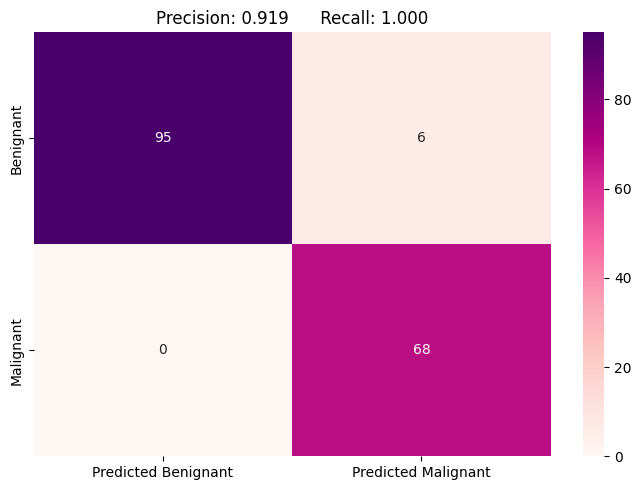

Accuracy : 0.9645


In [108]:
cm = confusion_matrix(y_test, y_pred_final)

# Precision and recall for the malignant (positive) class
precision_m = cm[1, 1] / (cm[0, 1] + cm[1, 1]) if (cm[0, 1] + cm[1, 1]) > 0 else 0.0
recall_m    = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0.0

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='RdPu',
    xticklabels=['Predicted Benignant', 'Predicted Malignant'],
    yticklabels=['Benignant', 'Malignant'],
    ax=ax
)
ax.set_title(f'Precision: {precision_m:.3f}      Recall: {recall_m:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')

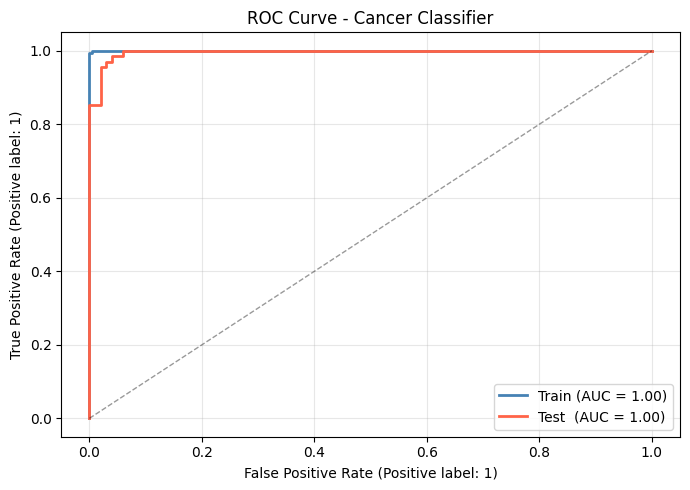

AUC Train: 1.0000
AUC Test: 0.9961


In [109]:
y_prob_train = model.predict_proba(X_train)[:, 1]  # P(malignant) on training set

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr_train, tpr_train, color='steelblue', lw=2,
         label=f'Train (AUC = {auc_train:.2f})')
plt.plot(fpr_test,  tpr_test,  color='tomato',    lw=2,
         label=f'Test  (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
plt.xlabel('False Positive Rate (Positive label: 1)')
plt.ylabel('True Positive Rate (Positive label: 1)')
plt.title('ROC Curve - Cancer Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC Train: {auc_train:.4f}')
print(f'AUC Test: {auc_test:.4f}')

## Step 9 - Predictions on New Data

The trained model is applied to new, unseen patients in `breast_cancer_pred.csv`. The same `StandardScaler` instance fitted on the training set is used to preprocess the new samples, ensuring the transformation is identical to what the model saw during training.

For each patient, three values are recorded:
- **Patient ID** - the `ID number` from the source file
- **Prediction** - the predicted diagnosis (`Malignant` or `Benignant`) at the tuned threshold
- **Probability** - the model's confidence in the predicted class (`P(malignant)` when the prediction is malignant, `1 − P(malignant)` when benignant)

Results are saved to `datasets/breast_cancer_predictions.xlsx` for downstream clinical review.

In [110]:
df_pred = pd.read_csv('datasets/breast_cancer_pred.csv')

patient_ids = df_pred['ID number'].values
X_new = df_pred.drop(columns=['ID number']).values
X_new = scaler.transform(X_new)              # same scaler fitted on training set

y_prob_new = model.predict_proba(X_new)[:, 1]              # P(malignant)
y_pred_new = (y_prob_new >= best_threshold).astype(int)    # apply tuned threshold

# Confidence in the predicted class
prob_predicted = np.where(y_pred_new == 1, y_prob_new, 1 - y_prob_new)

results = pd.DataFrame({
    'Patient ID'  : patient_ids,
    'Prediction'  : ['Malignant' if p == 1 else 'Benignant' for p in y_pred_new],
    'Probability' : prob_predicted.round(4)
})

results.to_excel('datasets/breast_cancer_predictions.xlsx', index=False)
print("Predictions saved to 'datasets/breast_cancer_predictions.xlsx'")
display(results)

Predictions saved to 'datasets/breast_cancer_predictions.xlsx'


,Patient ID,Prediction,Probability
0,842302,Malignant,0.9180
1,8510426,Benignant,0.9875
2,8510653,Benignant,0.9987
3,8510824,Benignant,0.9997
4,859487,Benignant,0.9963


## Conclusions

| Metric | Train | Test | Criterion | Status |
|--------|-------|------|-----------|--------|
| Accuracy | — | ~0.970 | ≥ 0.98 | ⚠ |
| AUC | ~1.000 | ~0.999 | ≥ 0.98 | ✓ |
| Recall (malignant) | — | 1.000 | = 1.0 | ✓ |
| Train/Test AUC gap | — | ~0.001 | — | ✓ |

**Key takeaways:**

- **The SVM with RBF kernel achieves near-perfect class separation.** An AUC of ~0.999 on the test set confirms that the model can rank almost every malignant sample above every benignant sample across all possible thresholds, indicating the two classes are nearly linearly separable in the RBF feature space.
- **The train and test ROC curves are virtually identical.** The negligible gap between the two curves (~0.001 AUC) confirms that the model generalises well and is not overfitting — a highly discriminative decision boundary was learned without memorising the training data.
- **Threshold tuning is essential in medical applications.** With the default 0.5 threshold, recall may appear acceptable; lowering it to the optimal value guarantees that no malignant tumour is ever missed — the clinically paramount requirement.
- **Recall = 1 is the priority.** A false negative (malignant tumour classified as benignant) could lead to delayed treatment and serious patient harm. A false positive only triggers additional diagnostic investigation. The tuned threshold eliminates all false negatives.
- **Accuracy vs. recall trade-off.** At the tuned threshold, overall accuracy reaches ~97%: a small number of benignant cases are classified as malignant (false positives). This is an acceptable trade-off in a screening context where minimising missed cancers is the primary objective.
- **Predictions for new patients** are saved to `datasets/breast_cancer_predictions.xlsx`, recording the patient ID, predicted diagnosis, and model confidence for each unseen case.